# Why Python?

Representing mathematical equations in machine language is not an easy task. Programming languages like Assembly, Fortran, Cobol and Basic are typically optimal for the computer's execution, but are difficult in terms of human readability and interpretation. The syntax of python makes it easy to quickly write out ideas and translate *"pseudo-code"* into actual code - minimizing the time it takes to develop a proof-of-concept or prototype. Using jupyter notebooks extends the flexibility of python by pairing it with markdown, allowing for a broader, less technical audience to participate, learn and contribute.

Notebooks are great for conducting business measurement and analysis of various data sets. Ultimately, using python will help achieve optimized **time-to-results**. There are generally three considerations that you should have when developing a new notebook:

- *Efficiency*
- *Productivity*
- *Quality*

Regardless of the scale or size of a python project, quality must always be considered. It is important that people are able to anticipate where there is opportunity after looking at a quant analysis. The examples in this notebook are from O'Reily's Python for Finance book.


## Valuation of European Call Option
### Monte Carlo Simulation

This valuation is considering a Black-Scholes-Merton (BSM) setup in which the option's underlying risk factor follows a geometric Brownian motion. Below I'll list the numerical valuation:

- Initial stock index level *S*<sub>0</sub> = 100
- Strike price of the European call option *K* = 105
- Time-to-maturity *T* = 1 year
- Constant, riskless short rate *r = 5%*
- Constant volatility *σ = 20%*

In the BSM model, the index level at maturity is a random variable, given by Equation 1-1 with z being a standard normally distributed random variable.
<br></br>
$
\begin{align}
S_T = S_0exp((r-\frac{1}{2}\sigma^2)T+\sigma\sqrt{T_z})
\end{align}
$

In [1]:
from numpy import *

In [2]:
S0 = 100. # Initial index level
K = 105. # strike price
T = 1.0 # time-to-maturity
r = 0.05 # riskless short rate
sigma = 0.2 # volatility
I = 100000 # number of simulations
z = random.standard_normal(I) # pseudo-random numbers
# index values at maturity
ST = S0 * exp((r - 0.5 * sigma ** 2) * T + sigma * sqrt(T) * z)
hT = maximum(ST - K,0)
C0 = exp(-r * T) * sum(hT) / I

In [3]:
print("Value of the European call option: %5.3f" % C0)

Value of the European call option: 7.924


## Lilly Stock Prices

Analyze the historical stock prices for around five years and analyze the volatility of the stock.There are three things needed in order to do this analysis:

- Download Lilly Stock Price data
- Calculate the rolling standard deviation of log returns (volatility)
- Plot the stock price data and the results

In [4]:
# import the scientific libraries from pypi.org
import numpy as np
import pandas as pd
from pandas_datareader import data as web

In [5]:
lly = web.DataReader('LLY', data_source='yahoo', start='7/15/2018', end='3/27/2022')
lly.tail()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2022-03-21,295.329987,287.760010,287.760010,289.640015,3495700.0,288.667267
2022-03-22,290.559998,283.390015,289.670013,285.019989,3791600.0,284.062744
2022-03-23,288.179993,283.350006,284.420013,284.190002,3149200.0,283.235565
2022-03-24,288.850006,284.660004,286.290009,287.690002,2412400.0,286.723785
2022-03-25,291.649994,286.579987,288.500000,289.019989,2399800.0,288.049316


### Calculate Volatility
Volatility measures price movement of a given stock. Highly volatile stocks will fluctuate between highs and lows erratically, while low volatility means that the stock stays fairly consistent in price. This is done by measuring the rolling standard deviation of logarithmic returns from the stock price history.


In [6]:
lly['Log_Ret'] = np.log(lly['Close']/lly['Close'].shift(1))
lly['Volatility'] = lly['Log_Ret'].rolling(252).std() * np.sqrt(252)

array([<AxesSubplot:xlabel='Date'>, <AxesSubplot:xlabel='Date'>],
      dtype=object)

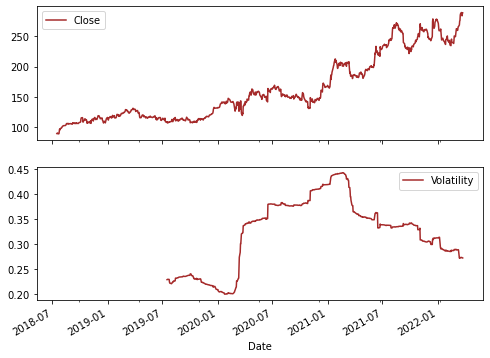

In [7]:
%matplotlib inline
lly[['Close', 'Volatility']].plot(subplots=True, color='brown', figsize=(8,6))

## Considerations
Three important concepts to keep in mind while coding are the 'Paradigm', 'Compiling', and 'Parallelization'.

**Paradigm**

*Libraries, frameworks, and governance strucutre matter when it comes to selecting projects and implementing solutions with python. Built-in frameworks/libraries can dramatically improve results for a gievn task or analysis*

**Compliling**

*Compiling is how code is translated from the programming language into machine code. There are several performance libraries available for python that provide compiled versions of important functions or compile python code statically/dynamically (at run or call time). These include Cython and Numba*

**Parallelization**

*Parallelization means executing tasks at the same time (typically autonomously). This concept is important for all programming languages, but python's syntax makes it increadibly easy to efficiently execute tasks in parallel*

## Prototyping to Production
### Scalability

Alongside these considerations, we want to look at efficiency metrics and testing configurations. Python is an extremely versatile language, capable of productionized execution. 

In a traditional business setting, the flow of data is cut into two halfs: the quantitative analysis vs development and implementation. Development often means a *'paradigm shift'* occurs, where languages like Java and C++ are used to fulfill production requirements after a series of quants has been performed and visualized. The popularization of python's syntax, coupled with it's abstracted class structure can address three major gaps that exist in the traditional design process:

- Inefficiencies
- Diverse Skill Sets
- Legacy Code

Good python code is able to address inefficiencies by implementing libraries and reusable functions that can perform multiple, complex tasks. The traditional design process, where a paradigm shift occurs, often leads to departments using different languages to implement "the same things". This can cause a number of issues, including significant data loss between quant analysis and production implementation. The code used for production is the code that needs to be maintained. When a lot of differnt languages are used, maintaining systems can quickly become overly complex and raise the expenses associated to maintainance.

Below we will analyze three unique implementations for the same algorithm. This shows the viability of using python for production, but only when the right implementation approach and plan are executed. Keep in mind, the desired outcome matters. If you need to design and use an intuitive UI, python is likely not the choice. The languages mentioned above are also not the right choice though. We would look to JavaScript to achieve this outcome. Python is typically considered a 'Backend' language. Python does offer fully fledged web frameworks that can be productionized in tandem with JavaScript. A couple of examples are [flask](https://flask.palletsprojects.com/en/2.0.x/) and [django](https://www.djangoproject.com/).

In [8]:
loops = 25000000
from math import *
a = range(1, loops)
def f(x):
    return 3 * log(x) + cos(x) ** 2
%timeit r = [f(x) for x in a]

10.1 s ± 239 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [9]:
import numpy as np
a = np.arange(1, loops)
%timeit r = 3 * np.log(a) + np.cos(a) ** 2

951 ms ± 12.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
import numexpr as ne
ne.set_num_threads(1)
f = '3 * log(a) + cos(a) ** 2'
%timeit r = ne.evaluate(f)

840 ms ± 29.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
ne.set_num_threads(4)
%timeit r = ne.evaluate(f)

387 ms ± 29.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Data-Driven, AI-First Finance
### Eikon Data APIs

The scientific method starts with a set of data and then allows for ideas, hypotheses, models, and strategies to be devised from that data. With artificial intelligence, we are now able to quickly gather data, group it, analyze it and visualize it. As a demonstration, we can connect into the [Eikon Data APIs](https://pypi.org/project/eikon/) and start to evaluate stocks. 

We don't have access to the eikon API, so I'm using [pandas](https://buildmedia.readthedocs.org/media/pdf/pandas-datareader/stable/pandas-datareader.pdf) for free.

In [12]:
import datetime as dt
import pandas as pd
import pandas_datareader.data as io

In [13]:
start_date = '2018-10-18 16:00:00'
end_date = '2018-10-18 17:00:00'

In [14]:
df = io.DataReader('BTC-USD', 'yahoo', start_date, end_date)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1 entries, 2018-10-19 to 2018-10-19
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       1 non-null      float64
 1   Low        1 non-null      float64
 2   Open       1 non-null      float64
 3   Close      1 non-null      float64
 4   Volume     1 non-null      int64  
 5   Adj Close  1 non-null      float64
dtypes: float64(5), int64(1)
memory usage: 56.0 bytes
None


## Strategy Measurement
Using the end of day data collected for apple stock, we can create a machine-learning based trading stratey and then measure the stratey against the benchmark. This is a concise example to show how quickly this can be developed in python. Trading strategy details will be covered in later chapters. First pull the ticker data over the course of 12 years from Amazon. We can easily apply the same measurement and analysis for any stock by switching the initial parameter in our request to yahoo.

In [15]:
start_date = '2010-01-01 16:00:00'
end_date = '2022-01-01 17:00:00'

In [16]:
data = io.DataReader('AMZN', 'yahoo', start_date, end_date)
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3021 entries, 2010-01-04 to 2021-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       3021 non-null   float64
 1   Low        3021 non-null   float64
 2   Open       3021 non-null   float64
 3   Close      3021 non-null   float64
 4   Volume     3021 non-null   int64  
 5   Adj Close  3021 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 165.2 KB


In [17]:
# calculate log returns over entire dataset
data['Returns'] = np.log(data['Close']/data['Close'].shift(1))
data.dropna(inplace=True)

In [18]:
lags = 6

In [19]:
cols = []
for lag in range(1, lags+1):
    col = 'lag_{}'.format(lag)
    data[col] = np.sign(data['Returns'].shift(lag))
    cols.append(col)
    
data.dropna(inplace=True)

In [20]:
from sklearn.svm import SVC
model = SVC(gamma='auto')

In [21]:
model.fit(data[cols], np.sign(data['Returns']))
SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0, 
    decision_function_shape='ovr', degree=3, gamma='auto', kernel='rbf', 
    max_iter=-1, probability=False, random_state=None, shrinking=True, 
    tol=0.001, verbose=False)

SVC(gamma='auto')

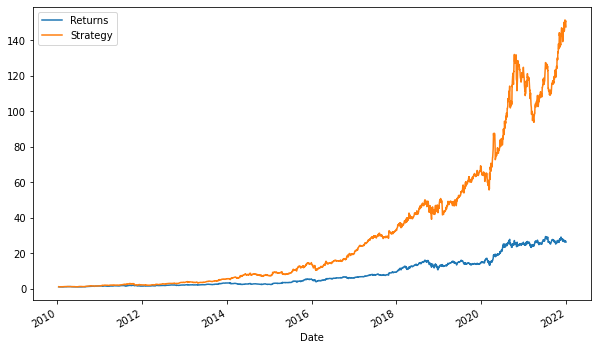

In [22]:
data['Prediction'] = model.predict(data[cols])
data['Strategy'] = data['Prediction'] * data['Returns']
data[['Returns', 'Strategy']].cumsum().apply(np.exp).plot(figsize=(10, 6));

## Analyze News Feeds
Python is extensible and simple in terms of syntax and development. It can be used to quickly add and test features for a given strategy. Consider how you might want to analyze and store context about your portfolio of shares. It might be useful to try and embed additional features into a trading strategy. I've created and stored the model in another notebook that is able to pull articles about a given keyword and analyze the sentiment across the articles. 

The data from that model is loaded here and graphed on a time-series plot to show an example of how we can take unstructured data into account when considering market analysis/trend data. The point is to show a time-series plot of sentiment analysis. We could consider a feature in our trading strategy that weights sentiment when considering short/long trade decisions.

In [23]:
# todo: improve and show examples
import os
import json

## Conclusions
AI requires domain expertise in tandem with computational processes. Python is an excellent choice for exploring AI, as it is a  diverse language with extensible open-source libraries and packages. The community and resources available for the language make it a pleasure to work with and it is production ready when it comes to implementing machine learning tasks.